# Multi-energy UniTensor slab fit on real ZnPc XRR

Refinement of the legacy DFT three-slab GlobalObjective (`dft_en_offset_new2`) in refloxide. Companion to `real_data_repl.py` and `bookended_real_data_fit.ipynb`.

Loads all energies from `reflectivity_data.parquet` (sibling `refl-analysis` checkout). Each energy is a legacy pyref s/p concat (split where `Q` resets); first chunk remaps to native `pol="p"`, second to native `pol="s"`.

**Stack:** vacuum / ZnPc surface / bulk / interface / SiO2 / Si. ZnPc layers are `UniTensorSLD` on `dft.csv`, seeded from the DFT-fit extraction. Oxide and Si start from the free-tensor fit (`free_en_offset_init_2`). Instrument corrections are seeded from the DFT fit (theta labels swapped to native channels).

**Refinement contract (matched $k=101$):** free the same parameter classes as the legacy DFT slab, including SiO₂ `thick`/`rough`/`density` and Si `rough`/`density`. Surface density keeps an upper ceiling; interface (sub-layer) density is hard-capped **below** bulk so it cannot invert into a denser sub-film. Surface/interface tilt $\gamma$ is boxed **below the magic angle** ($\arccos 1/\sqrt{3}\approx 54.7^\circ$, optically isotropic) and near the DFT seeds (~52.2° / ~47°). Bounds are otherwise narrow windows about the DFT seeds so this is a refinement, not a free re-exploration.

**Workflow**

1. Seed structure + instruments from `dft_en_offset_new2`; build the UniTensor stack.
2. Apply matched-$k$ free flags and DFT-centered bounds (interface density reseeded below bulk).
3. Refinement: L-BFGS-B on instruments, DE on geometry, DE on both, then L-BFGS-B polish + Hessian `stderr`.
4. Overlay, depth profiles, model-selection ($\chi^2_\nu$, AIC, BIC) vs legacy, save.


In [53]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import json
import os
import pickle
import time
from pathlib import Path

os.environ["POLARS_VERBOSE"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from refnx.analysis import CurveFitter, Transform

from refloxide.data import OpticalConstants, ReflectDataset
from refloxide.model import MaterialSLD, ReflectModel, UniTensorSLD
from refloxide.objective import Objective, thread_workers


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Paths and DFT-slab seeds

Geometry and per-energy instrument corrections come from the DFT-fit extraction (`dft_en_offset_new2_summary.json`), the same published three-slab model used in fig_3. This notebook refines that model rather than transplanting free-tensor geometry.


In [54]:
ZNPC_DFT_CSV = Path.home() / "projects/refl-analysis/@models/optical/znpc/dft.csv"
ZNPC_DATA = (
    Path.home() / "projects/refl-analysis/@data/xrr/znpc/reflectivity_data.parquet"
)
DFT_DIR = Path.home() / "projects/refl-analysis/@models/xrr/znpc/dft"
FREE_DIR = Path.home() / "projects/refl-analysis/@models/xrr/znpc/free"
DFT_SUMMARY_PATH = DFT_DIR / "dft_en_offset_new2_summary.json"
FREE_SUMMARY_PATH = FREE_DIR / "free_en_offset_init_2_summary.json"
for path in (ZNPC_DFT_CSV, ZNPC_DATA, DFT_SUMMARY_PATH, FREE_SUMMARY_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"missing {path} -- expects sibling refl-analysis checkout, "
            "dft_en_offset_new2 extraction, and free_en_offset_init_2 extraction "
            "(summary mirrors free_en_offset_init_2.pkl without requiring pyref)"
        )

dft_summary = json.loads(DFT_SUMMARY_PATH.read_text())
free_summary = json.loads(FREE_SUMMARY_PATH.read_text())
dft_layers = {layer["name"]: layer for layer in dft_summary["layers"]}
free_layers = {layer["name"]: layer for layer in free_summary["layers"]}
surface_dft = dft_layers["Surface"]
bulk_dft = dft_layers["ZnPc"]
interface_dft = dft_layers["Contamination"]
oxide_dft = dft_layers["Oxide"]
substrate_dft = dft_layers["Substrate"]
oxide_free = free_layers["Oxide"]
substrate_free = free_layers["Substrate"]

Q_MIN = 0.0001


def nc_limit(rough: float) -> float:
    return float(np.sqrt(2.0 * np.pi) * rough / 2.0)


def resolve_nc(thick: float, rough: float) -> tuple[float, float]:
    """Project (thick, rough) onto the nearest Nevot-Croce-feasible point."""
    limit = nc_limit(rough)
    if thick >= limit:
        return thick, rough
    thick_proj = limit
    rough_proj = float(2.0 * thick / np.sqrt(2.0 * np.pi))
    if abs(thick_proj - thick) <= abs(rough - rough_proj):
        return thick_proj, rough
    return thick, rough_proj


def seed_window(
    value: float, half_width: float, lo: float, hi: float
) -> tuple[float, float]:
    """DFT-centered box clipped to physical ``[lo, hi]``."""
    return (max(lo, value - half_width), min(hi, value + half_width))


SURFACE = {
    "thick": float(surface_dft["thick"]),
    "rough": float(surface_dft["rough"]),
    "density": float(surface_dft["density"]),
    "rotation": float(surface_dft["rotation"]),
}
BULK = {
    "thick": float(bulk_dft["thick"]),
    "rough": float(bulk_dft["rough"]),
    "density": float(bulk_dft["density"]),
    "rotation": float(bulk_dft["rotation"]),
}
INTERFACE = {
    "thick": float(interface_dft["thick"]),
    "rough": float(interface_dft["rough"]),
    "density": float(interface_dft["density"]),
    "rotation": float(interface_dft["rotation"]),
}
# Oxide / Si: start from the free-tensor fit (free_en_offset_init_2), not DFT.
# Isotropic MaterialSLD density is meaningful there; film free-tensor slabs are not.
OXIDE = {
    "thick": float(oxide_free["thick"]),
    "rough": float(oxide_free["rough"]),
    "density": float(oxide_free["density"]),
}
SUBSTRATE = {
    "rough": float(substrate_free["rough"]),
    "density": float(substrate_free["density"]),
}

# Film layers only: keep DFT oxide frozen even if it sits below NC
# (legacy GlobalObjective did; Objective uses nc_constraint=False below).
for name, layer in (("SURFACE", SURFACE), ("BULK", BULK), ("INTERFACE", INTERFACE)):
    thick0, rough0 = layer["thick"], layer["rough"]
    layer["thick"], layer["rough"] = resolve_nc(thick0, rough0)
    if (layer["thick"], layer["rough"]) != (thick0, rough0):
        print(
            f"NC snap {name}: thick {thick0:.4f}->{layer['thick']:.4f}, "
            f"rough {rough0:.4f}->{layer['rough']:.4f}"
        )

# Native-channel instrument seeds from DFT (theta labels swapped).
DFT_INSTRUMENT = {
    float(c["energy"]): (
        float(c["scale_s"]),
        float(c["scale_p"]),
        float(c["theta_offset_p"]),
        float(c["theta_offset_s"]),
        float(c["bkg"]),
        float(c["energy_offset"]),
    )
    for c in dft_summary["corrections"]
}

print(f"dft.csv:     {ZNPC_DFT_CSV}")
print(f"data:        {ZNPC_DATA}")
print(f"dft summary: {DFT_SUMMARY_PATH}")
print(f"free summary:{FREE_SUMMARY_PATH}")
print(
    "DFT seeds — surface/bulk/interface dens: "
    f"{SURFACE['density']:.4f} / {BULK['density']:.4f} / {INTERFACE['density']:.4f}"
)
print(
    "oxide seed from FREE (DFT was "
    f"thick={float(oxide_dft['thick']):.4f}, rough={float(oxide_dft['rough']):.4f}, "
    f"dens={float(oxide_dft['density']):.4f}): "
    f"thick={OXIDE['thick']:.4f} A, rough={OXIDE['rough']:.4f} A, "
    f"density={OXIDE['density']:.4f} g/cm^3"
)
print(
    "substrate seed from FREE (DFT was "
    f"rough={float(substrate_dft['rough']):.4f}, dens={float(substrate_dft['density']):.4f}): "
    f"rough={SUBSTRATE['rough']:.4f} A, "
    f"density={SUBSTRATE['density']:.4f} g/cm^3"
)
print(f"instrument channels: {len(DFT_INSTRUMENT)}")


dft.csv:     /Users/hduva/projects/refl-analysis/@models/optical/znpc/dft.csv
data:        /Users/hduva/projects/refl-analysis/@data/xrr/znpc/reflectivity_data.parquet
dft summary: /Users/hduva/projects/refl-analysis/@models/xrr/znpc/dft/dft_en_offset_new2_summary.json
free summary:/Users/hduva/projects/refl-analysis/@models/xrr/znpc/free/free_en_offset_init_2_summary.json
DFT seeds — surface/bulk/interface dens: 1.8000 / 1.6385 / 1.8000
oxide seed from FREE (DFT was thick=6.8794, rough=8.1267, dens=1.9212): thick=8.8372 A, rough=5.0922 A, density=2.2627 g/cm^3
substrate seed from FREE (DFT was rough=1.2000, dens=2.5025): rough=1.2000 A, density=2.3657 g/cm^3
instrument channels: 21


## Load reflectivity data

All energies from `reflectivity_data.parquet`. Legacy first chunk is native `R_pp` (`pol="p"`); second chunk is native `R_ss` (`pol="s"`).


In [55]:
parts = []
for _, g in pl.read_parquet(ZNPC_DATA).group_by("energy", maintain_order=True):
    q = g["Q"].to_numpy()
    cut = np.flatnonzero(np.diff(q) < 0)
    i = int(cut[0] + 1) if cut.size else len(q)
    pol = np.where(np.arange(len(q)) < i, "p", "s")
    parts.append(g.with_columns(pl.Series("pol", pol)))

frame = (
    pl.concat(parts)
    .rename({"Q": "q", "R": "r", "dR": "r_err"})
    .filter(pl.col("q") >= Q_MIN)
    .select("q", "energy", "pol", "r", "r_err")
)
dataset = ReflectDataset.from_polars(frame)
energies = sorted(frame["energy"].unique().to_list())
print(
    f"ReflectDataset: {len(dataset)} rows, "
    f"{len(list(dataset.groups()))} groups, energies={energies}"
)


ReflectDataset: 2765 rows, 42 groups, energies=[250.0, 275.0, 280.0, 281.0, 281.2, 281.4, 281.6, 281.8, 282.0, 282.3, 282.5, 282.7, 282.9, 283.1, 283.3, 283.5, 283.7, 284.2, 285.1, 287.0, 289.0]


## Measured data overview


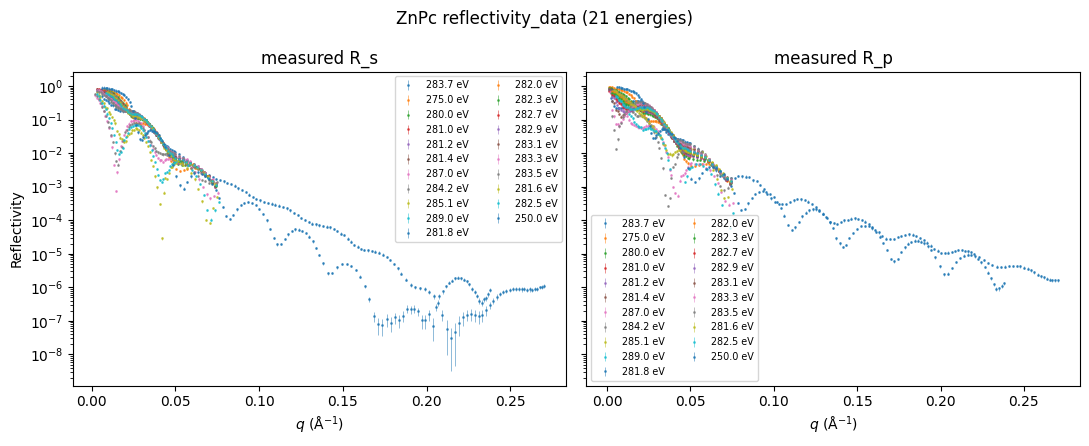

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for energy, pol, indices in dataset.groups():
    ax = axes[0] if pol == "s" else axes[1]
    ax.errorbar(
        dataset.q[indices],
        dataset.r[indices],
        yerr=dataset.r_err[indices],
        fmt=".",
        ms=2,
        lw=0.5,
        alpha=0.7,
        label=f"{energy:.1f} eV",
    )
axes[0].set_title("measured R_s")
axes[1].set_title("measured R_p")
for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
    ax.legend(fontsize="x-small", ncol=2)
axes[0].set_ylabel("Reflectivity")
fig.suptitle(f"ZnPc reflectivity_data ({len(energies)} energies)")
fig.tight_layout()
plt.show()


## UniTensor stack

One shared `OpticalConstants` across ZnPc surface / bulk / interface. Oxide and substrate are isotropic `MaterialSLD`.


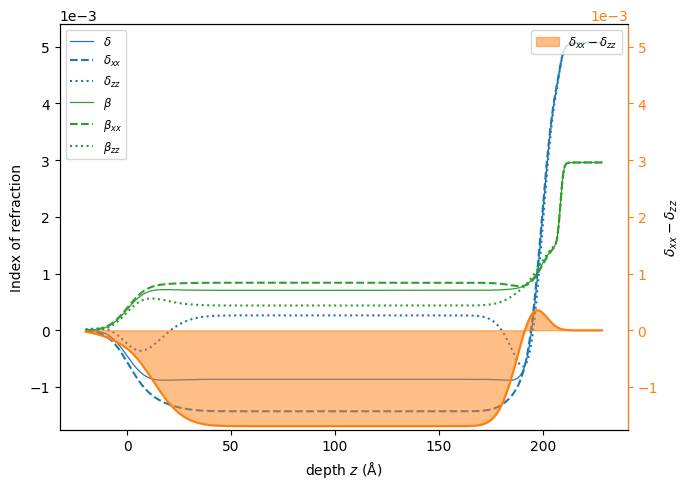

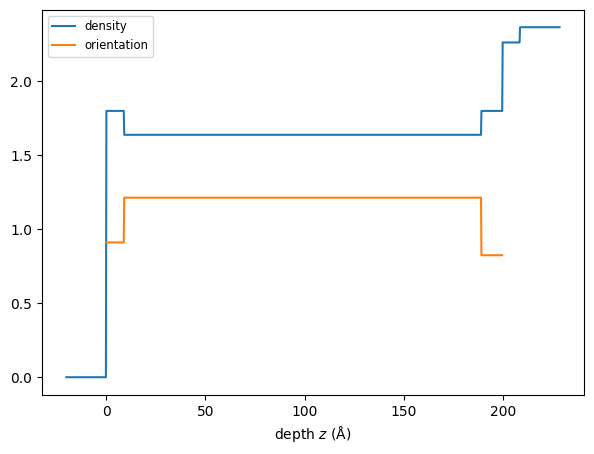

In [57]:
znpc_ooc = OpticalConstants.from_file(ZNPC_DFT_CSV)


def build_structure():
    vacuum = MaterialSLD("", 0, name="vacuum")(0, 0)
    surface = UniTensorSLD(
        znpc_ooc,
        density=SURFACE["density"],
        rotation=SURFACE["rotation"],
        name="ZnPc_surface",
    )(SURFACE["thick"], SURFACE["rough"])
    bulk = UniTensorSLD(
        znpc_ooc,
        density=BULK["density"],
        rotation=BULK["rotation"],
        name="ZnPc_bulk",
    )(BULK["thick"], BULK["rough"])
    interface = UniTensorSLD(
        znpc_ooc,
        density=INTERFACE["density"],
        rotation=INTERFACE["rotation"],
        name="ZnPc_interface",
    )(INTERFACE["thick"], INTERFACE["rough"])
    oxide = MaterialSLD("SiO2", density=OXIDE["density"], name="oxide")(
        OXIDE["thick"], OXIDE["rough"]
    )
    substrate = MaterialSLD("Si", density=SUBSTRATE["density"], name="substrate")(
        0, SUBSTRATE["rough"]
    )
    return vacuum | surface | bulk | interface | oxide | substrate


model = ReflectModel(build_structure(), energies=energies, parallel=False)
structure = model.structure
surface = structure.slab("ZnPc_surface")
bulk = structure.slab("ZnPc_bulk")
interface = structure.slab("ZnPc_interface")
assert surface.sld.ooc is bulk.sld.ooc is interface.sld.ooc is znpc_ooc
assert surface.enforce_nevot_croce and bulk.enforce_nevot_croce
assert interface.enforce_nevot_croce and structure.slab("oxide").enforce_nevot_croce
assert not structure.slab("vacuum").enforce_nevot_croce
assert not structure.slab("substrate").enforce_nevot_croce

print(structure)
structure.plot.oc(283.7, difference=True)
plt.show()
structure.plot.param("density|orientation")
plt.show()


## Matched-$k$ refinement bounds

Seeded at the DFT slab. Free parameters match the full legacy GlobalObjective ($k=101$), including SiO₂ and Si. Interface density is reseeded and boxed strictly below bulk. Surface/interface rotation stays anisotropic (upper bound below the magic angle) near the DFT tilts (~52.2° / ~47°).

- Surface density: upper-bounded (DFT seed was hard against 1.8)
- Interface (sub-layer) density: lower-bounded so the transition stays less dense than bulk
- All other free geometry/instruments: narrow DFT-centered windows


In [58]:
def nc_thick_lower(rough_upper: float) -> float:
    return nc_limit(rough_upper)


def snap_into_bounds(
    thick: float,
    rough: float,
    *,
    thick_bounds: tuple[float, float],
    rough_bounds: tuple[float, float],
    frac: float = 1e-9,
) -> tuple[float, float]:
    """Clamp thick/rough into box bounds, then project onto Nevot-Croce."""
    thick_lo, thick_hi = thick_bounds
    rough_lo, rough_hi = rough_bounds
    thick_span = thick_hi - thick_lo
    rough_span = rough_hi - rough_lo
    thick_lo_i = thick_lo + frac * thick_span
    thick_hi_i = thick_hi - frac * thick_span
    rough_lo_i = rough_lo + frac * rough_span
    rough_hi_i = rough_hi - frac * rough_span
    thick_c = float(np.clip(thick, thick_lo_i, thick_hi_i))
    rough_c = float(np.clip(rough, rough_lo_i, rough_hi_i))
    thick_r, rough_r = resolve_nc(thick_c, rough_c)
    thick_r = float(np.clip(thick_r, thick_lo_i, thick_hi_i))
    rough_r = float(np.clip(rough_r, rough_lo_i, rough_hi_i))
    thick_r, rough_r = resolve_nc(thick_r, rough_r)
    if thick_r < thick_lo_i or thick_r > thick_hi_i:
        thick_r = thick_lo_i
        rough_r = min(rough_r, 2.0 * thick_r / np.sqrt(2.0 * np.pi))
        rough_r = float(np.clip(rough_r, rough_lo_i, rough_hi_i))
    return thick_r, rough_r


# Narrow refinement windows about DFT seeds.
SCALE_DELTA = 0.08
SCALE_LO, SCALE_HI = 0.75, 1.45
THETA_DELTA = 0.08

# Surface density: upper bound at the DFT ceiling (1.8); allow lower.
SURFACE_DENSITY_BOUNDS = (1.2, 1.8)
BULK_DENSITY_BOUNDS = seed_window(BULK["density"], 0.15, 1.3, 1.9)
# Interface / sub-layer must stay strictly below bulk (legacy DFT seed is 1.8).
INTERFACE_DENSITY_BOUNDS = (0.1, 1)

# Uniaxial tilt gamma. Magic angle arccos(1/sqrt(3)) ~ 54.74 deg is optically
# isotropic (vanishing dichroism); the previous +/-0.20 rad windows allowed the
# surface to park there (~55 deg). Keep surface/interface anisotropic and near DFT.
MAGIC_ANGLE = float(np.arccos(1.0 / np.sqrt(3.0)))
SURFACE_ROTATION_BOUNDS = (
    max(0.0, SURFACE["rotation"] - np.deg2rad(3.0)),
    min(MAGIC_ANGLE - np.deg2rad(1.5), SURFACE["rotation"] + np.deg2rad(1.5)),
)
INTERFACE_ROTATION_BOUNDS = (
    max(0.0, INTERFACE["rotation"] - np.deg2rad(4.0)),
    min(MAGIC_ANGLE - np.deg2rad(3.0), INTERFACE["rotation"] + np.deg2rad(2.5)),
)
BULK_ROTATION_BOUNDS = seed_window(BULK["rotation"], 0.10, 0.0, np.pi / 2)
assert SURFACE_ROTATION_BOUNDS[1] < MAGIC_ANGLE
assert INTERFACE_ROTATION_BOUNDS[1] < MAGIC_ANGLE
assert SURFACE_ROTATION_BOUNDS[0] < SURFACE_ROTATION_BOUNDS[1]
assert INTERFACE_ROTATION_BOUNDS[0] < INTERFACE_ROTATION_BOUNDS[1]

SURFACE_ROUGH_HI = max(SURFACE["rough"] + 2.0, SURFACE["rough"] * 1.15)
INTERFACE_ROUGH_HI = max(INTERFACE["rough"] + 2.0, INTERFACE["rough"] * 1.15)
BULK_ROUGH_HI = max(BULK["rough"] + 2.0, BULK["rough"] * 1.1)

SURFACE_THICK_BOUNDS = seed_window(
    SURFACE["thick"], 4.0, nc_thick_lower(SURFACE_ROUGH_HI), 25.0
)
SURFACE_ROUGH_BOUNDS = seed_window(SURFACE["rough"], 2.5, 0.5, SURFACE_ROUGH_HI)
INTERFACE_THICK_BOUNDS = seed_window(
    INTERFACE["thick"], 4.0, nc_thick_lower(INTERFACE_ROUGH_HI), 25.0
)
INTERFACE_ROUGH_BOUNDS = seed_window(
    INTERFACE["rough"], 2.5, 0.5, INTERFACE_ROUGH_HI
)
BULK_THICK_BOUNDS = seed_window(BULK["thick"], 8.0, 160.0, 200.0)
BULK_ROUGH_BOUNDS = seed_window(BULK["rough"], 2.0, 5.0, BULK_ROUGH_HI)

oxide = structure.slab("oxide")
substrate = structure.slab("substrate")

surface_thick0, surface_rough0 = snap_into_bounds(
    SURFACE["thick"],
    SURFACE["rough"],
    thick_bounds=SURFACE_THICK_BOUNDS,
    rough_bounds=SURFACE_ROUGH_BOUNDS,
)
interface_thick0, interface_rough0 = snap_into_bounds(
    INTERFACE["thick"],
    INTERFACE["rough"],
    thick_bounds=INTERFACE_THICK_BOUNDS,
    rough_bounds=INTERFACE_ROUGH_BOUNDS,
)
bulk_thick0, bulk_rough0 = snap_into_bounds(
    BULK["thick"],
    BULK["rough"],
    thick_bounds=BULK_THICK_BOUNDS,
    rough_bounds=BULK_ROUGH_BOUNDS,
)

for param in model.parameters.flattened():
    param.vary = False

# --- full DFT free set (k=101): film + SiO2 + Si + instruments ---
OXIDE_THICK_BOUNDS = seed_window(OXIDE["thick"], 3.0, 2.0, 20.0)
OXIDE_ROUGH_BOUNDS = seed_window(OXIDE["rough"], 2.0, 0.5, 15.0)
oxide.thick.setp(value=OXIDE["thick"], vary=True, bounds=OXIDE_THICK_BOUNDS)
oxide.rough.setp(value=OXIDE["rough"], vary=True, bounds=OXIDE_ROUGH_BOUNDS)
oxide.sld.density.setp(
    value=OXIDE["density"],
    vary=True,
    bounds=seed_window(OXIDE["density"], 0.25, 1.5, 2.4),
)

substrate.rough.setp(
    value=SUBSTRATE["rough"],
    vary=True,
    bounds=seed_window(SUBSTRATE["rough"], 0.4, 0.5, 3.0),
)
substrate.sld.density.setp(
    value=SUBSTRATE["density"],
    vary=True,
    bounds=seed_window(SUBSTRATE["density"], 0.15, 2.0, 2.8),
)

bulk.thick.setp(value=bulk_thick0, vary=True, bounds=BULK_THICK_BOUNDS)
bulk.rough.setp(value=bulk_rough0, vary=True, bounds=BULK_ROUGH_BOUNDS)
bulk.sld.density.setp(
    value=BULK["density"], vary=True, bounds=BULK_DENSITY_BOUNDS
)
bulk.sld.rotation.setp(
    value=BULK["rotation"],
    vary=True,
    bounds=BULK_ROTATION_BOUNDS,
)

surface.thick.setp(value=surface_thick0, vary=True, bounds=SURFACE_THICK_BOUNDS)
surface.rough.setp(value=surface_rough0, vary=True, bounds=SURFACE_ROUGH_BOUNDS)
surface.sld.density.setp(
    value=min(SURFACE["density"], SURFACE_DENSITY_BOUNDS[1] - 1e-6),
    vary=True,
    bounds=SURFACE_DENSITY_BOUNDS,
)
surface.sld.rotation.setp(
    value=float(
        np.clip(
            SURFACE["rotation"],
            SURFACE_ROTATION_BOUNDS[0] + 1e-6,
            SURFACE_ROTATION_BOUNDS[1] - 1e-6,
        )
    ),
    vary=True,
    bounds=SURFACE_ROTATION_BOUNDS,
)

interface.thick.setp(value=interface_thick0, vary=True, bounds=INTERFACE_THICK_BOUNDS)
interface.rough.setp(value=interface_rough0, vary=True, bounds=INTERFACE_ROUGH_BOUNDS)
interface.sld.density.setp(
    value=min(INTERFACE["density"], INTERFACE_DENSITY_BOUNDS[1] - 1e-6),
    vary=True,
    bounds=INTERFACE_DENSITY_BOUNDS,
)
interface.sld.rotation.setp(
    value=float(
        np.clip(
            INTERFACE["rotation"],
            INTERFACE_ROTATION_BOUNDS[0] + 1e-6,
            INTERFACE_ROTATION_BOUNDS[1] - 1e-6,
        )
    ),
    vary=True,
    bounds=INTERFACE_ROTATION_BOUNDS,
)

energy_offsets = {v[5] for v in DFT_INSTRUMENT.values()}
assert len(energy_offsets) == 1
model.energy_offset.setp(value=energy_offsets.pop(), vary=False)

for energy, (sc_s, sc_p, th_s, th_p, bkg, _eoff) in DFT_INSTRUMENT.items():
    model.scale_s.at(energy).setp(
        value=sc_s,
        vary=True,
        bounds=(max(SCALE_LO, sc_s - SCALE_DELTA), min(SCALE_HI, sc_s + SCALE_DELTA)),
    )
    model.scale_p.at(energy).setp(
        value=sc_p,
        vary=True,
        bounds=(max(SCALE_LO, sc_p - SCALE_DELTA), min(SCALE_HI, sc_p + SCALE_DELTA)),
    )
    model.theta_offset_s.at(energy).setp(
        value=th_s,
        vary=True,
        bounds=(th_s - THETA_DELTA, th_s + THETA_DELTA),
    )
    model.theta_offset_p.at(energy).setp(
        value=th_p,
        vary=True,
        bounds=(th_p - THETA_DELTA, th_p + THETA_DELTA),
    )
    model.bkg.at(energy).setp(value=bkg, vary=False)

model.parallel = False

# DFT oxide violates NC; match legacy by not rejecting on that frozen slab.
objective = Objective(
    model, dataset, transform=Transform("logY"), nc_constraint=False
)
n_vary = len(objective.varying_parameters())
print(f"nc_constraint={objective.nc_constraint}")
print(f"energies: {len(energies)}, batches: {len(objective._batches)}")
print(f"varying parameters k={n_vary} (target 101 = full DFT free set)")
print(
    f"surface density bounds={SURFACE_DENSITY_BOUNDS}, "
    f"interface density bounds={INTERFACE_DENSITY_BOUNDS} "
    f"(capped below bulk={BULK['density']:.4f})"
)
print(
    "rotation deg bounds — "
    f"surface=[{np.rad2deg(SURFACE_ROTATION_BOUNDS[0]):.1f}, "
    f"{np.rad2deg(SURFACE_ROTATION_BOUNDS[1]):.1f}], "
    f"interface=[{np.rad2deg(INTERFACE_ROTATION_BOUNDS[0]):.1f}, "
    f"{np.rad2deg(INTERFACE_ROTATION_BOUNDS[1]):.1f}] "
    f"(magic={np.rad2deg(MAGIC_ANGLE):.2f} deg excluded)"
)
assert n_vary == 101, f"expected matched k=101, got {n_vary}"
assert np.isfinite(objective.logp()), "starting point must lie inside box bounds"
print(f"logl at DFT seed: {float(objective.logl()):.3f}")
print(
    "interface dens seed = "
    f"{float(interface.sld.density.value):.4f} "
    f"(DFT raw={INTERFACE['density']:.4f})"
)
print(
    "surface/interface rotation seed deg = "
    f"{np.rad2deg(float(surface.sld.rotation.value)):.2f} / "
    f"{np.rad2deg(float(interface.sld.rotation.value)):.2f}"
)
print(
    "oxide density seed = "
    f"{float(oxide.sld.density.value):.4f} "
    f"(FREE={OXIDE['density']:.4f}; DFT was {float(oxide_dft['density']):.4f})"
)
print(
    "si density seed = "
    f"{float(substrate.sld.density.value):.4f} "
    f"(FREE={SUBSTRATE['density']:.4f}; DFT was {float(substrate_dft['density']):.4f})"
)

nc_constraint=False
energies: 21, batches: 42
varying parameters k=101 (target 101 = full DFT free set)
surface density bounds=(1.2, 1.8), interface density bounds=(0.1, 1) (capped below bulk=1.6385)
rotation deg bounds — surface=[49.2, 53.2], interface=[43.2, 49.7] (magic=54.74 deg excluded)
logl at DFT seed: -11721.979
interface dens seed = 1.0000 (DFT raw=1.8000)
surface/interface rotation seed deg = 52.21 / 47.24
oxide density seed = 2.2627 (FREE=2.2627; DFT was 1.9212)
si density seed = 2.3657 (FREE=2.3657; DFT was 2.5025)


## Refinement fit (all energies)

Four stages from the DFT seed:

1. **L-BFGS-B** — instruments only (geometry frozen)
2. **DE** — geometry only (instruments frozen at stage-1 values)
3. **DE** — geometry + instruments together
4. **L-BFGS-B polish** — full free set, then attach local-Hessian `stderr` on every varying parameter

Stage 4 is a dedicated L-BFGS-B, not `DE(polish=True)`. `CurveFitter` only writes `Parameter.stderr` when `res.success` is True; DE often returns `success=False` after hitting `maxiter` even if SciPy polished, which left geometry blank while stage-1 instrument errors lingered.

Rayon stays off; DE uses `thread_workers`.


In [59]:
GEOMETRY_SLABS = (surface, bulk, interface)


def set_instrument_vary(active: bool) -> None:
    for energy in energies:
        model.scale_s.at(energy).vary = active
        model.scale_p.at(energy).vary = active
        model.theta_offset_s.at(energy).vary = active
        model.theta_offset_p.at(energy).vary = active


def set_geometry_vary(active: bool, final: bool = False) -> None:
    for slab in GEOMETRY_SLABS:
        slab.thick.vary = active
        slab.rough.vary = active
        slab.sld.density.vary = active
        slab.sld.rotation.vary = active
    oxide.thick.vary = active
    oxide.rough.vary = active
    oxide.sld.density.vary = final
    substrate.rough.vary = active
    substrate.sld.density.vary = final


def nudge_varying_inside_bounds(objective: Objective, *, frac: float = 1e-9) -> list[float]:
    """Move varying values strictly inside box bounds for SciPy DE ``x0``."""
    x0: list[float] = []
    for param in objective.varying_parameters():
        bounds = param.bounds
        value = float(param.value or 0.0)
        if bounds is None or not hasattr(bounds, "lb"):
            x0.append(value)
            continue
        lo = float(bounds.lb)
        hi = float(bounds.ub)
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            x0.append(value)
            continue
        span = hi - lo
        nudged = float(np.clip(value, lo + frac * span, hi - frac * span))
        if nudged != value:
            param.value = nudged
        x0.append(nudged)
    return x0


def run_lbfgsb(label: str, *, maxiter: int = 500) -> None:
    n_vary = len(objective.varying_parameters())
    print(f"\n{label}: {n_vary} varying parameters")
    print(f"  logl before: {float(objective.logl()):.3f}")
    assert np.isfinite(objective.logp()), f"{label}: start outside bounds"
    nudge_varying_inside_bounds(objective)
    t0 = time.perf_counter()
    res = CurveFitter(objective).fit(
        method="L-BFGS-B",
        options={"maxiter": maxiter},
    )
    print(
        f"  L-BFGS-B maxiter={maxiter}: {time.perf_counter() - t0:.2f} s, "
        f"success={getattr(res, 'success', None)}, "
        f"logl={float(objective.logl()):.3f}"
    )


def attach_stderr_from_covar(objective: Objective) -> int:
    """Write local-Hessian stderr onto every varying Parameter.

    ``CurveFitter.fit`` only assigns ``stderr`` when ``res.success`` is True.
    DE (and L-BFGS-B that hits ``maxiter``) often returns ``success=False``
    even after SciPy's internal polish, so geometry stays blank while leftover
    stage-1 instrument stderrs remain. Always attach after the final mode.
    """
    varying = list(objective.varying_parameters())
    errors = np.sqrt(np.diag(np.asarray(objective.covar(), dtype=float)))
    for param in objective.parameters.flattened():
        param.stderr = None
        param.chain = None
    n_ok = 0
    for param, err in zip(varying, errors, strict=True):
        if np.isfinite(err):
            param.stderr = float(err)
            n_ok += 1
    return n_ok


def run_de(
    label: str, *, maxiter: int, popsize: int, polish: bool
) -> None:
    n_vary = len(objective.varying_parameters())
    print(f"\n{label}: {n_vary} varying parameters")
    print(f"  logl before: {float(objective.logl()):.3f}")
    assert np.isfinite(objective.logp()), f"{label}: start outside bounds"
    x0 = nudge_varying_inside_bounds(objective)
    with thread_workers(12) as workers:
        workers.bind(objective)
        t0 = time.perf_counter()
        CurveFitter(objective).fit(
            method="differential_evolution",
            popsize=popsize,
            maxiter=maxiter,
            polish=polish,
            seed=1,
            workers=workers,
            updating="deferred",
            x0=x0,
        )
        print(
            f"  DE maxiter={maxiter} polish={polish}: "
            f"{time.perf_counter() - t0:.2f} s, "
            f"logl={float(objective.logl()):.3f}"
        )


logl_before = float(objective.logl())
print(f"bulk thick start = {bulk.thick.value:.2f}")
print(f"logl at DFT seed: {logl_before:.3f}")

# Stage 1: instruments only (local polish of scales/theta at fixed DFT geometry).
set_geometry_vary(False)
set_instrument_vary(True)
run_lbfgsb("stage 0: L-BFGS-B instruments only", maxiter=500)

# Stage 2: geometry only (instruments held at stage-1 values).
set_instrument_vary(False)
set_geometry_vary(True)
run_lbfgsb("stage 1: L-BFGS-B geometry only", maxiter=500)

# Stage 1: instruments only (local polish of scales/theta at fixed DFT geometry).
set_geometry_vary(True)
set_instrument_vary(True)
run_lbfgsb("stage 2: L-BFGS-B instruments + geometry", maxiter=500)


# Stage 3: joint DE on the full matched-k set.
set_instrument_vary(True)
set_geometry_vary(True)
run_de("stage 3: DE geometry + instruments", maxiter=50, popsize=12, polish=False)

# Stage 4: dedicated L-BFGS-B polish on the full free set.
# Do not use DE polish=True for this — CurveFitter skips stderr when
# res.success is False (common when DE hits maxiter even after polish).
set_geometry_vary(True, final=True)
run_lbfgsb("stage 4: L-BFGS-B polish", maxiter=2000)
n_err = attach_stderr_from_covar(objective)
print(f"parameters with stderr: {n_err}/{len(objective.varying_parameters())}")
assert n_err == len(objective.varying_parameters())

logl_after = float(objective.logl())
recovered = float(bulk.thick.value or 0.0)
print(f"\nrecovered bulk thick = {recovered:.2f} A")
print(f"energy_offset = {model.energy_offset.value:.4f} eV")
print(f"logl after:  {logl_after:.3f}")
print(f"delta logl = {logl_after - logl_before:.3f}")
assert np.isfinite(logl_before) and np.isfinite(logl_after)
print("surface dens =", float(surface.sld.density.value))
print("bulk dens    =", float(bulk.sld.density.value))
print("interface dens =", float(interface.sld.density.value))
print(f"final k = {len(objective.varying_parameters())}")
print(objective)


bulk thick start = 179.95
logl at DFT seed: -11721.979

stage 0: L-BFGS-B instruments only: 84 varying parameters
  logl before: -11721.979


8936.272026718509: : 26it [00:13,  1.89it/s]


  L-BFGS-B maxiter=500: 14.72 s, success=True, logl=-8936.272

stage 1: L-BFGS-B geometry only: 15 varying parameters
  logl before: -8936.272


3940.332205666018: : 155it [00:17,  9.10it/s] 


  L-BFGS-B maxiter=500: 17.23 s, success=True, logl=-3940.332

stage 2: L-BFGS-B instruments + geometry: 99 varying parameters
  logl before: -3940.332


...

  L-BFGS-B maxiter=500: 90.28 s, success=False, logl=-3618.564

stage 3: DE geometry + instruments: 99 varying parameters
  logl before: -3618.564


3618.5635290827695: : 50it [01:44,  2.10s/it]


  DE maxiter=50 polish=False: 104.84 s, logl=-3618.564

stage 4: L-BFGS-B polish: 101 varying parameters
  logl before: -3618.564


3559.081559271738: : 136it [01:31,  1.49it/s] 


  L-BFGS-B maxiter=2000: 91.49 s, success=False, logl=-3559.082
parameters with stderr: 101/101

recovered bulk thick = 176.63 A
energy_offset = 0.0035 eV
logl after:  -3559.082
delta logl = 8162.898
surface dens = 1.8
bulk dens    = 1.6073460008101408
interface dens = 1.0
final k = 101
________________________________________________________________________________
Objective - reflectivity_objective
Dataset = <None>, 2765 points
datapoints = 2765
chi2 = 20441.519361110153
Weighted = True
Transform = Transform('logY')
________________________________________________________________________________
Parameters: 'reflect_model'
________________________________________________________________________________
Parameters: 'experiment_corrections'
________________________________________________________________________________
Parameters:    'shared'    
<Parameter:'energy_offset', value=0.00349378  (fixed) , bounds=[-1.0, 1.0]>
<Parameter:     'dq'      , value=0  (fixed) , bounds=[-inf, inf

## Overlay data vs fit


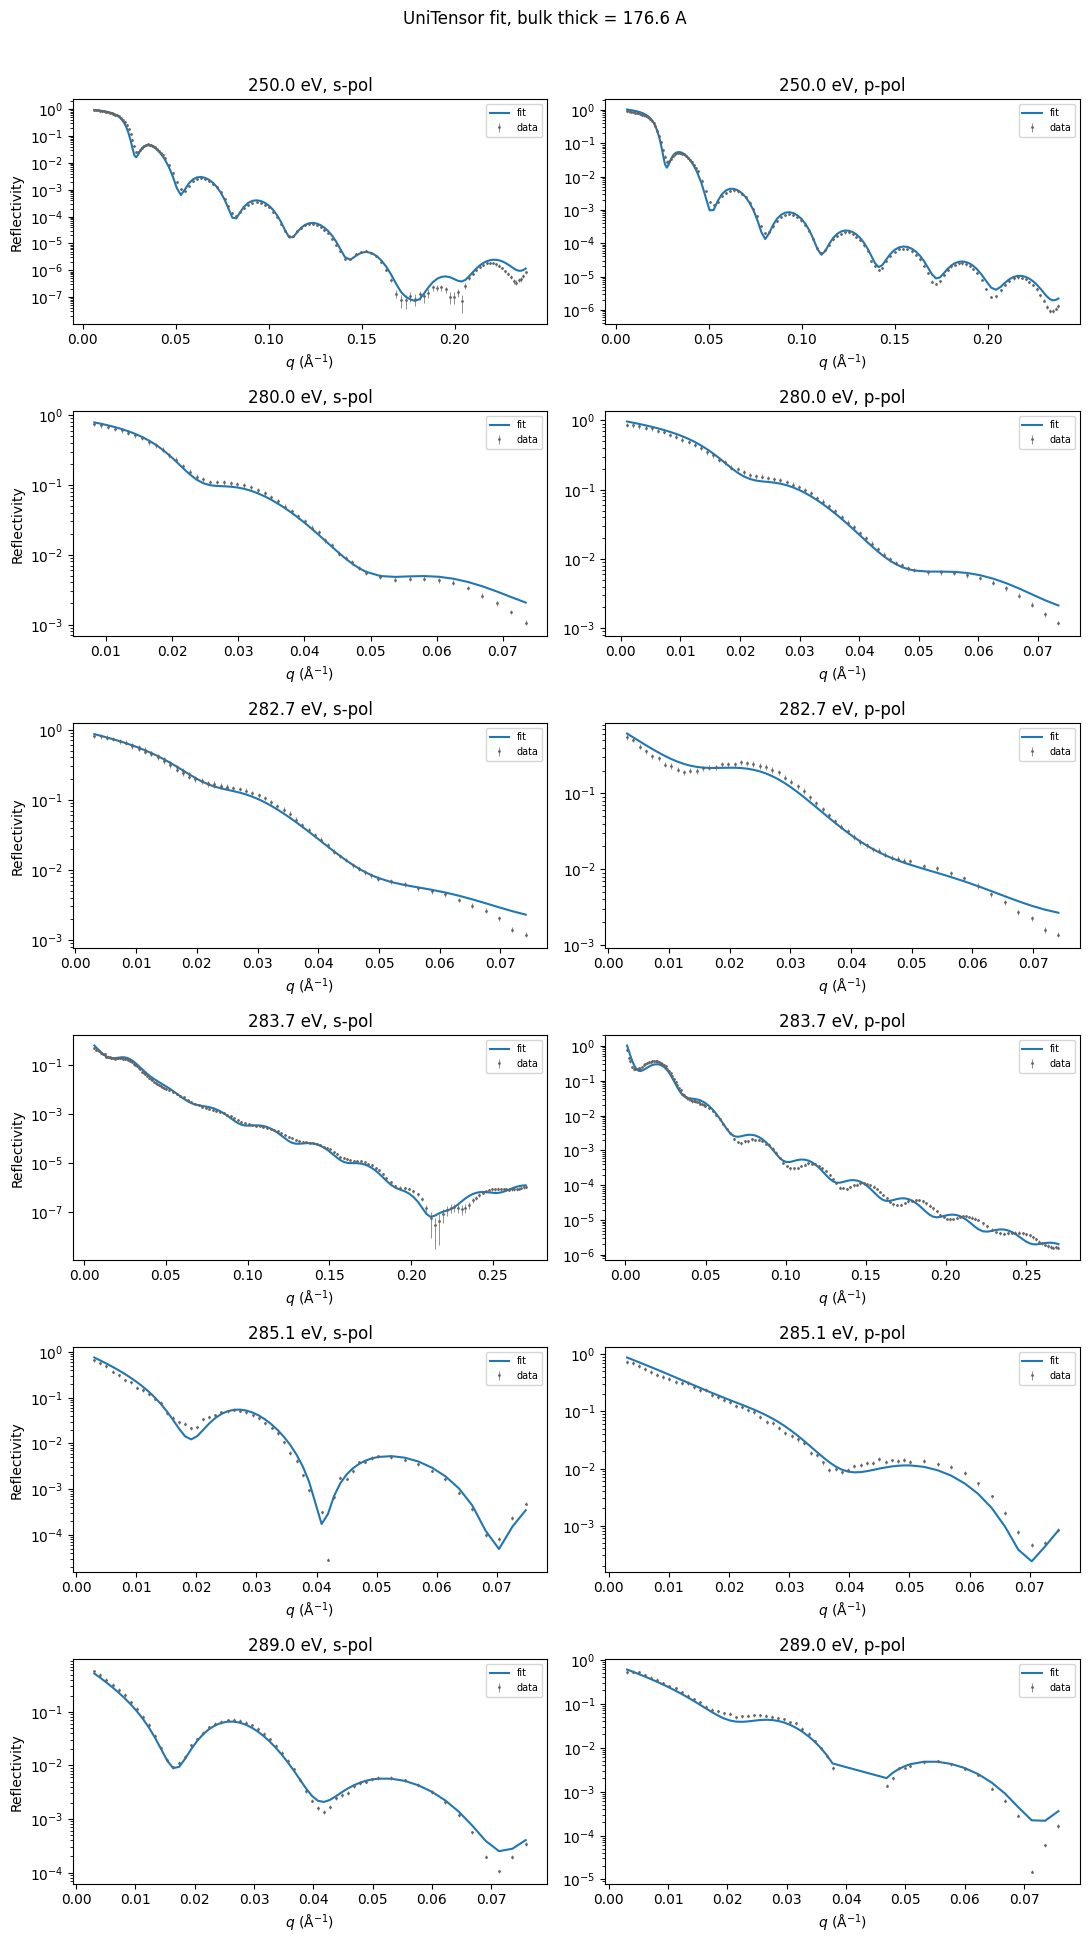

In [60]:
show_energies = (250.0, 280.0, 282.7, 283.7, 285.1, 289.0)
fig, axes = plt.subplots(len(show_energies), 2, figsize=(11, 3.2 * len(show_energies)))
for row, energy in enumerate(show_energies):
    for col, pol in enumerate(("s", "p")):
        ax = axes[row, col]
        for e, p, indices in dataset.groups():
            if e != energy or p != pol:
                continue
            q = dataset.q[indices]
            ax.errorbar(
                q,
                dataset.r[indices],
                yerr=dataset.r_err[indices],
                fmt=".",
                ms=2,
                lw=0.5,
                color="0.4",
                label="data",
            )
            pred = model(q, energy)
            ax.plot(
                q,
                pred.s if pol == "s" else pred.p,
                color="C0",
                lw=1.5,
                label="fit",
            )
        ax.set_yscale("log")
        ax.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
        ax.set_title(f"{energy:.1f} eV, {pol}-pol")
        if col == 0:
            ax.set_ylabel("Reflectivity")
        ax.legend(fontsize="x-small")
fig.suptitle(f"UniTensor fit, bulk thick = {recovered:.1f} A", y=1.01)
fig.tight_layout()
plt.show()


## Orientation / density profiles after fit


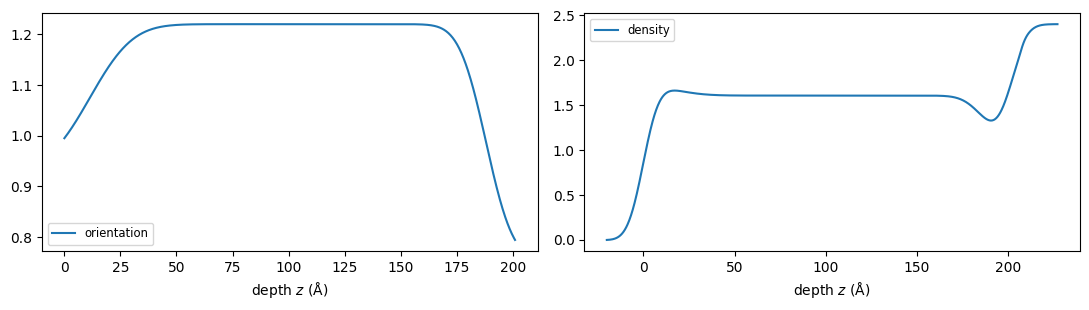

________________________________________________________________________________
Parameters:      None      
<Parameter:'scale_s@250p0eV', value=1.04835 +/- 0.0132, bounds=[1.0483522692686418, 1.208352269268642]>
<Parameter:'scale_p@250p0eV', value=1.17289 +/- 0.0147, bounds=[1.1728872111914304, 1.3328872111914305]>
<Parameter:'theta_offset_s@250p0eV', value=0.356196 +/- 0.0152, bounds=[0.35619553461953757, 0.5161955346195376]>
<Parameter:'theta_offset_p@250p0eV', value=0.588418 +/- 0.0154, bounds=[0.5884181562322595, 0.7484181562322594]>
<Parameter:'scale_s@275p0eV', value=0.968565 +/- 0.018, bounds=[0.8399899759552172, 0.9999899759552171]>
<Parameter:'scale_p@275p0eV', value=1.02953 +/- 0.0177, bounds=[0.9021197274269422, 1.0621197274269423]>
<Parameter:'theta_offset_s@275p0eV', value=0.141218 +/- 0.0257, bounds=[0.1247067522452029, 0.2847067522452029]>
<Parameter:'theta_offset_p@275p0eV', value=0.472259 +/- 0.0261, bounds=[0.4529773505772066, 0.6129773505772066]>
<Parameter:'scale_s

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
structure.plot.param("orientation", ax=axes[0], roughness=True)
structure.plot.param("density", ax=axes[1], roughness=True)
fig.tight_layout()
plt.show()

print(objective.varying_parameters())


## Compare against the legacy DFT-fit GlobalObjective

Independent re-fit against comparable data (same `dft.csv` OOC and 283.7 eV anchor stack). Legacy layer names map as Surface / ZnPc / Contamination to surface / bulk / interface. Exact agreement is not expected; the question is how far the geometries diverge. Requires the one-time extraction from `dft_model_comparison_repl.py`.


In [62]:
DFT_DIR = Path.home() / "projects/refl-analysis/@models/xrr/znpc/dft"
DFT_SUMMARY_PATH = DFT_DIR / "dft_en_offset_new2_summary.json"
DFT_DATA_PATH = DFT_DIR / "dft_en_offset_new2_data.parquet"
for path in (DFT_SUMMARY_PATH, DFT_DATA_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"missing {path} -- run the one-time extraction described in "
            "dft_model_comparison_repl.py first"
        )

dft_summary = json.loads(DFT_SUMMARY_PATH.read_text())
dft_frame = pl.read_parquet(DFT_DATA_PATH)
dft_layers = {layer["name"]: layer for layer in dft_summary["layers"]}


ROLE_MAP = {
    "ZnPc_surface": ("Surface", surface),
    "ZnPc_bulk": ("ZnPc", bulk),
    "ZnPc_interface": ("Contamination", interface),
}

print(f"{'role':<16}{'param':<10}{'ours':>12}{'legacy DFT':>12}{'delta':>12}")
for our_name, (legacy_name, slab) in ROLE_MAP.items():
    legacy = dft_layers[legacy_name]
    params = [
        ("thick", float(slab.thick.value or 0.0), legacy["thick"]),
        ("rough", float(slab.rough.value or 0.0), legacy["rough"]),
        ("density", float(slab.sld.density.value or 0.0), legacy["density"]),
        ("rotation", float(slab.sld.rotation.value or 0.0), legacy["rotation"]),
    ]
    for param, ours, legacy_v in params:
        print(
            f"{our_name:<16}{param:<10}{ours:>12.4f}{legacy_v:>12.4f}"
            f"{ours - legacy_v:>12.4f}"
        )

legacy_oxide = dft_layers["Oxide"]
for param, ours in (
    ("thick", float(oxide.thick.value or 0.0)),
    ("rough", float(oxide.rough.value or 0.0)),
    ("density", float(oxide.sld.density.value or 0.0)),
):
    legacy_v = legacy_oxide[param]
    delta = ours - legacy_v
    print(f"{'oxide':<16}{param:<10}{ours:>12.4f}{legacy_v:>12.4f}{delta:>12.4f}")


role            param             ours  legacy DFT       delta
ZnPc_surface    thick          11.3500      8.9335      2.4165
ZnPc_surface    rough           6.9065      7.0560     -0.1495
ZnPc_surface    density         1.8000      1.8000      0.0000
ZnPc_surface    rotation        0.9291      0.9112      0.0179
ZnPc_bulk       thick         176.6252    179.9515     -3.3262
ZnPc_bulk       rough          15.1047     13.1363      1.9684
ZnPc_bulk       density         1.6073      1.6385     -0.0312
ZnPc_bulk       rotation        1.2199      1.2137      0.0062
ZnPc_interface  thick          13.1489     10.7048      2.4441
ZnPc_interface  rough           9.4455      7.8924      1.5531
ZnPc_interface  density         1.0000      1.8000     -0.8000
ZnPc_interface  rotation        0.7547      0.8245     -0.0698
oxide           thick           5.8372      6.8794     -1.0422
oxide           rough           7.0922      8.1267     -1.0345
oxide           density         2.3344      1.9212     

## Reflectivity overlay vs legacy DFT fit

Data vs our fit vs the legacy DFT-fit prediction at 250 / 283.7 / 285.1 eV.


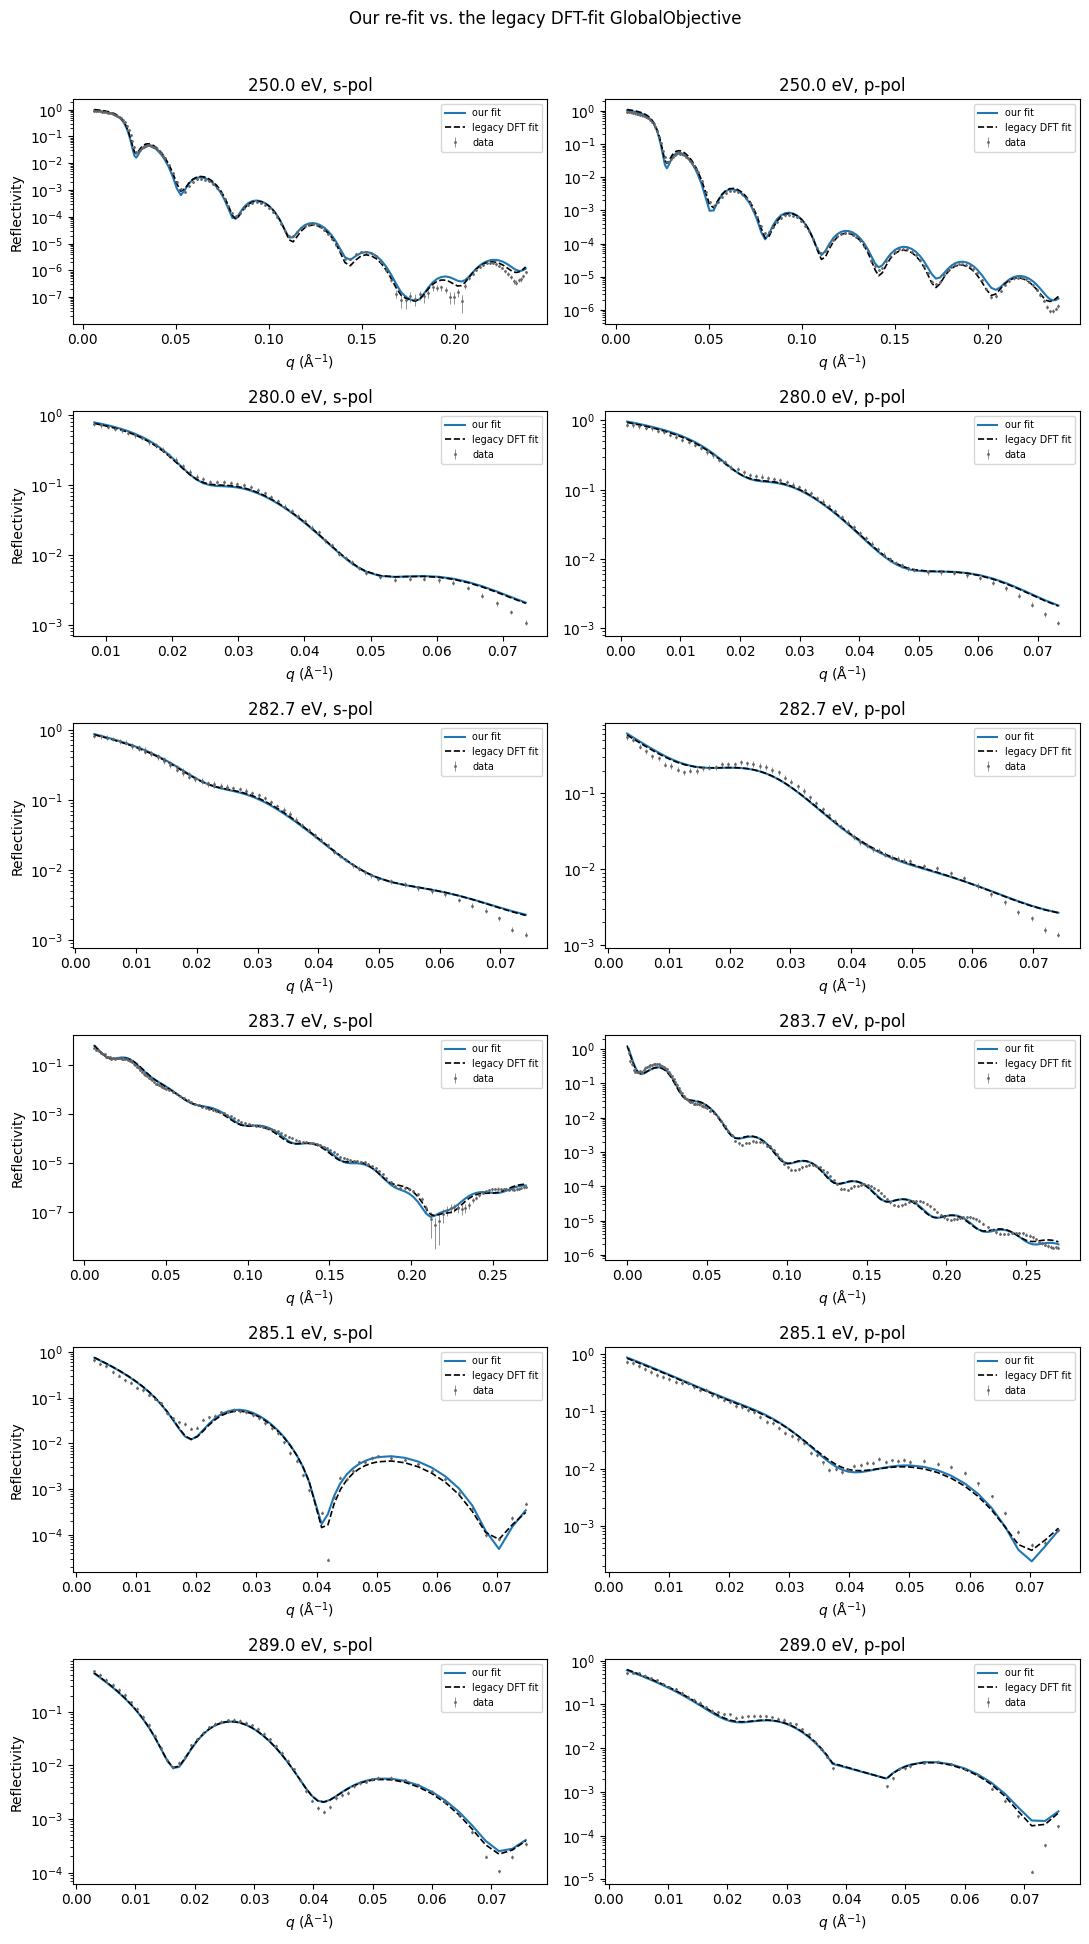

In [63]:
fig, axes = plt.subplots(len(show_energies), 2, figsize=(11, 3.2 * len(show_energies)))
for row, energy in enumerate(show_energies):
    legacy_group = dft_frame.filter(pl.col("energy") == energy)
    for col, pol in enumerate(("s", "p")):
        ax = axes[row, col]
        for e, p, indices in dataset.groups():
            if e != energy or p != pol:
                continue
            q = dataset.q[indices]
            ax.errorbar(
                q,
                dataset.r[indices],
                yerr=dataset.r_err[indices],
                fmt=".",
                ms=2,
                lw=0.5,
                color="0.4",
                label="data",
            )
            pred = model(q, energy)
            ax.plot(
                q,
                pred.s if pol == "s" else pred.p,
                color="C0",
                lw=1.5,
                label="our fit",
            )
        legacy_sub = legacy_group.filter(pl.col("pol") == pol)
        if not legacy_sub.is_empty():
            ax.plot(
                legacy_sub["q"].to_numpy(),
                legacy_sub["legacy_pred"].to_numpy(),
                color="k",
                ls="--",
                lw=1.2,
                label="legacy DFT fit",
            )
        ax.set_yscale("log")
        ax.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
        ax.set_title(f"{energy:.1f} eV, {pol}-pol")
        if col == 0:
            ax.set_ylabel("Reflectivity")
        ax.legend(fontsize="x-small")
fig.suptitle("Our re-fit vs. the legacy DFT-fit GlobalObjective", y=1.01)
fig.tight_layout()
plt.show()


In [64]:
print(objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:'scale_s@250p0eV', value=1.04835 +/- 0.0132, bounds=[1.0483522692686418, 1.208352269268642]>
<Parameter:'scale_p@250p0eV', value=1.17289 +/- 0.0147, bounds=[1.1728872111914304, 1.3328872111914305]>
<Parameter:'theta_offset_s@250p0eV', value=0.356196 +/- 0.0152, bounds=[0.35619553461953757, 0.5161955346195376]>
<Parameter:'theta_offset_p@250p0eV', value=0.588418 +/- 0.0154, bounds=[0.5884181562322595, 0.7484181562322594]>
<Parameter:'scale_s@275p0eV', value=0.968565 +/- 0.018, bounds=[0.8399899759552172, 0.9999899759552171]>
<Parameter:'scale_p@275p0eV', value=1.02953 +/- 0.0177, bounds=[0.9021197274269422, 1.0621197274269423]>
<Parameter:'theta_offset_s@275p0eV', value=0.141218 +/- 0.0257, bounds=[0.1247067522452029, 0.2847067522452029]>
<Parameter:'theta_offset_p@275p0eV', value=0.472259 +/- 0.0261, bounds=[0.4529773505772066, 0.6129773505772066]>
<Parameter:'scale_s

## Depth profile overlay

Our fitted structure vs the legacy DFT-fit structure, same `dft.csv` OOC anchor.


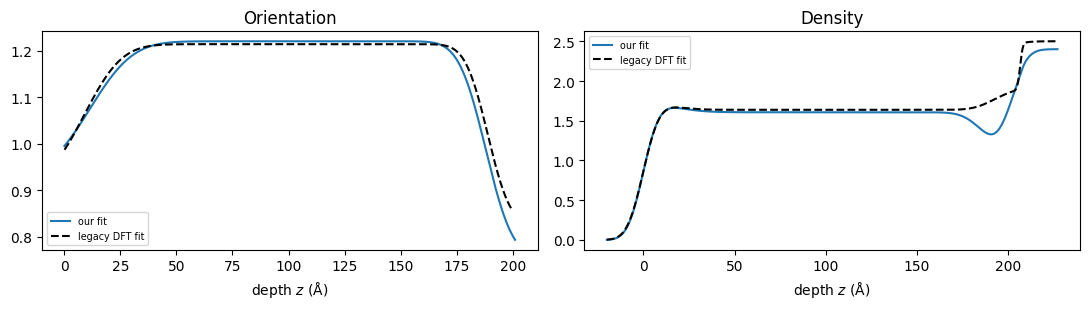

In [65]:
def build_legacy_structure():
    slabs = []
    for layer in dft_summary["layers"]:
        if layer["kind"] == "uniaxial":
            sld = UniTensorSLD(
                znpc_ooc,
                density=layer["density"],
                rotation=layer["rotation"],
                name=layer["name"],
            )
        else:
            sld = MaterialSLD(
                layer["formula"], density=layer["density"], name=layer["name"]
            )
        slabs.append(sld(layer["thick"], layer["rough"]))
    built = slabs[0]
    for slab in slabs[1:]:
        built = built | slab
    return built


legacy_structure = build_legacy_structure()
z_ours = structure.depth_grid(num_points=2000, pad=20.0)
z_legacy = legacy_structure.depth_grid(num_points=2000, pad=20.0)

_, density_ours = structure.density_profile_at(z_ours, roughness=True)
_, orientation_ours = structure.orientation_profile_at(z_ours, roughness=True)
_, density_legacy = legacy_structure.density_profile_at(z_legacy, roughness=True)
_, orientation_legacy = legacy_structure.orientation_profile_at(
    z_legacy, roughness=True
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(z_ours, orientation_ours, color="C0", label="our fit")
axes[0].plot(z_legacy, orientation_legacy, color="k", ls="--", label="legacy DFT fit")
axes[0].set_title("Orientation")
axes[0].set_xlabel(r"depth $z$ ($\mathrm{\AA}$)")
axes[0].legend(fontsize="x-small")

axes[1].plot(z_ours, density_ours, color="C0", label="our fit")
axes[1].plot(z_legacy, density_legacy, color="k", ls="--", label="legacy DFT fit")
axes[1].set_title("Density")
axes[1].set_xlabel(r"depth $z$ ($\mathrm{\AA}$)")
axes[1].legend(fontsize="x-small")
fig.tight_layout()
plt.show()


## Model selection: refloxide refinement vs legacy DFT slab

Same criteria as `refl-analysis/notebooks/manuscript/fig_3_orientation.ipynb`. Both models use the **same** free set ($k=101$: full DFT slab + instruments), scored on this notebook's `dataset` with `Transform("logY")`.


In [66]:
def model_selection_stats(objective: Objective, *, use_logl: bool = False):
    """Reduced chi2, AIC, and BIC from an Objective (fig_3_orientation convention)."""
    resid = np.asarray(objective.residuals(), dtype=float)
    n = int(resid.size)
    k = len(objective.varying_parameters())
    chi2 = float(np.sum(resid**2))
    nu = max(n - k, 1)
    if use_logl:
        logl = float(objective.logl())
        aic = 2.0 * k - 2.0 * logl
        bic = k * np.log(n) - 2.0 * logl
    else:
        aic = chi2 + 2.0 * k
        bic = chi2 + k * np.log(n)
    return {
        "chi2": chi2 / nu,
        "aic": aic,
        "bic": bic,
        "N": k,
        "npoints": n,
        "chi2_raw": chi2,
        "logl": float(objective.logl()),
    }


def log_model_weights(stats_dict: dict, key: str):
    """Log-space Akaike / BIC model weights (fig_3_orientation)."""
    names = list(stats_dict)
    vals = np.array([float(stats_dict[m][key]) for m in names])
    delta = vals - vals.min()
    ln_unnorm = -0.5 * delta
    ln_w = ln_unnorm - np.logaddexp.reduce(ln_unnorm)
    return dict(zip(names, ln_w, strict=True)), dict(zip(names, delta, strict=True))


def apply_matched_k_flags(model: ReflectModel) -> None:
    """Same free/fixed pattern as the refinement (k=101)."""
    for param in model.parameters.flattened():
        param.vary = False
    for name, keys in (
        ("Surface", ("thick", "rough", "density", "rotation")),
        ("ZnPc", ("thick", "rough", "density", "rotation")),
        ("Contamination", ("thick", "rough", "density", "rotation")),
    ):
        slab = model.structure.slab(name)
        for key in keys:
            if key in ("thick", "rough"):
                getattr(slab, key).vary = True
            else:
                getattr(slab.sld, key).vary = True
    oxide_l = model.structure.slab("Oxide")
    oxide_l.thick.vary = True
    oxide_l.rough.vary = True
    oxide_l.sld.density.vary = True
    sub_l = model.structure.slab("Substrate")
    sub_l.rough.vary = True
    sub_l.sld.density.vary = True
    for e in energies:
        model.scale_s.at(e).vary = True
        model.scale_p.at(e).vary = True
        model.theta_offset_s.at(e).vary = True
        model.theta_offset_p.at(e).vary = True


def build_legacy_dft_objective() -> Objective:
    """Rebuild the published DFT-slab fit with matched-k flags on ``dataset``."""
    slabs = []
    for layer in dft_summary["layers"]:
        if layer["kind"] == "uniaxial":
            sld = UniTensorSLD(
                znpc_ooc,
                density=layer["density"],
                rotation=layer["rotation"],
                name=layer["name"],
            )
        else:
            sld = MaterialSLD(
                layer["formula"], density=layer["density"], name=layer["name"]
            )
        slabs.append(sld(layer["thick"], layer["rough"]))
    built = slabs[0]
    for slab in slabs[1:]:
        built = built | slab

    legacy_model = ReflectModel(built, energies=energies, parallel=False)
    energy_offsets = {c["energy_offset"] for c in dft_summary["corrections"]}
    assert len(energy_offsets) == 1
    legacy_model.energy_offset.setp(value=energy_offsets.pop(), vary=False)

    for c in dft_summary["corrections"]:
        e = c["energy"]
        legacy_model.scale_s.at(e).setp(value=float(c["scale_s"]), vary=False)
        legacy_model.scale_p.at(e).setp(value=float(c["scale_p"]), vary=False)
        legacy_model.theta_offset_s.at(e).setp(
            value=float(c["theta_offset_p"]), vary=False
        )
        legacy_model.theta_offset_p.at(e).setp(
            value=float(c["theta_offset_s"]), vary=False
        )
        legacy_model.bkg.at(e).setp(value=float(c["bkg"]), vary=False)

    apply_matched_k_flags(legacy_model)
    return Objective(
        legacy_model, dataset, transform=Transform("logY"), nc_constraint=False
    )


# Align refit vary flags to the matched-k pattern (names differ on our stack).
set_instrument_vary(True)
set_geometry_vary(True)
ours_objective = objective
assert len(ours_objective.varying_parameters()) == 101

legacy_objective = build_legacy_dft_objective()
assert len(legacy_objective.varying_parameters()) == 101

STATS_USE_LOGL = True
stats = {
    "Legacy DFT slab": model_selection_stats(
        legacy_objective, use_logl=STATS_USE_LOGL
    ),
    "Refloxide refit": model_selection_stats(ours_objective, use_logl=STATS_USE_LOGL),
}
stats_chi2 = {
    "Legacy DFT slab": model_selection_stats(legacy_objective, use_logl=False),
    "Refloxide refit": model_selection_stats(ours_objective, use_logl=False),
}
stats_logl = {
    "Legacy DFT slab": model_selection_stats(legacy_objective, use_logl=True),
    "Refloxide refit": model_selection_stats(ours_objective, use_logl=True),
}

print(
    f"{'model':<18}{'n':>8}{'k':>6}{'chi2_nu':>10}"
    f"{'AIC_chi2':>12}{'BIC_chi2':>12}{'AIC_logl':>12}{'BIC_logl':>12}"
)
print("-" * 90)
for name in stats:
    c, lg = stats_chi2[name], stats_logl[name]
    print(
        f"{name:<18}{c['npoints']:>8d}{c['N']:>6d}{c['chi2']:>10.3f}"
        f"{c['aic']:>12.1f}{c['bic']:>12.1f}{lg['aic']:>12.1f}{lg['bic']:>12.1f}"
    )

d_aic_chi2 = stats_chi2["Refloxide refit"]["aic"] - stats_chi2["Legacy DFT slab"]["aic"]
d_aic_logl = stats_logl["Refloxide refit"]["aic"] - stats_logl["Legacy DFT slab"]["aic"]
d_bic_chi2 = stats_chi2["Refloxide refit"]["bic"] - stats_chi2["Legacy DFT slab"]["bic"]
d_bic_logl = stats_logl["Refloxide refit"]["bic"] - stats_logl["Legacy DFT slab"]["bic"]
print(
    f"\ndAIC agreement (chi2-form vs logl-form): {d_aic_chi2:.2f} vs {d_aic_logl:.2f}"
)
print(
    f"dBIC agreement (chi2-form vs logl-form): {d_bic_chi2:.2f} vs {d_bic_logl:.2f}"
)

_LN10 = float(np.log(10.0))
for key, label, ratio_name in (
    ("aic", "Akaike", "evidence ratio"),
    ("bic", "Bayes (BIC)", "Bayes factor"),
):
    ln_w, delta = log_model_weights(stats, key)
    d_pair = float(stats["Refloxide refit"][key] - stats["Legacy DFT slab"][key])
    log10_ratio = -0.5 * d_pair / _LN10
    w_refit = float(np.exp(ln_w["Refloxide refit"]))
    w_legacy = float(np.exp(ln_w["Legacy DFT slab"]))
    print(
        f"{label}: d{key.upper()}(refit - legacy) = {d_pair:.1f} | "
        f"log10 {ratio_name}(refit/legacy) = {log10_ratio:+.2f} | "
        f"P(refit) = {w_refit:.6f}, P(legacy) = {w_legacy:.6f}"
    )

refit_wins_aic = stats["Refloxide refit"]["aic"] < stats["Legacy DFT slab"]["aic"]
refit_wins_bic = stats["Refloxide refit"]["bic"] < stats["Legacy DFT slab"]["bic"]
refit_wins_chi2 = stats["Refloxide refit"]["chi2"] < stats["Legacy DFT slab"]["chi2"]
print("\nDrop-in replacement gate (lower is better, matched k=101):")
print(f"  reduced chi2_nu: refit {'WINS' if refit_wins_chi2 else 'LOSES'}")
print(f"  AIC:             refit {'WINS' if refit_wins_aic else 'LOSES'}")
print(f"  BIC:             refit {'WINS' if refit_wins_bic else 'LOSES'}")
if refit_wins_aic and refit_wins_bic:
    print("  => Refloxide refinement outperforms legacy DFT slab on AIC and BIC.")
else:
    print("  => Keep legacy DFT slab for fig_3 until the refinement wins AIC and BIC.")


AssertionError: 

## Save fitted objective

Writes a new pickle under `@models/xrr/znpc/refloxide/`, distinct from the legacy DFT and free-tensor inputs. Reload needs only refloxide.


In [23]:
FIT_OUT_DIR = Path.home() / "projects/refl-analysis/@models/xrr/znpc/refloxide"
FIT_OUT_DIR.mkdir(parents=True, exist_ok=True)
FIT_OUT_PATH = FIT_OUT_DIR / "refit-refloxide.pkl"

with FIT_OUT_PATH.open("wb") as f:
    pickle.dump(objective, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"saved fitted objective to {FIT_OUT_PATH}")


saved fitted objective to /Users/hduva/projects/refl-analysis/@models/xrr/znpc/refloxide/refit-refloxide.pkl
